# ResNet18 Top-1 vs Bits Comparison

This notebook loads the AIMET weight-only sweep and the NWC lambda sweep, then plots ImageNet top-1 accuracy for:

- Baseline quantization
- AdaRound
- NWC


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

AIMET_SWEEP_DIR = Path("/home/jgryu/workspace/weight_compression/comp_cnn/resnet18_weight_only_bw_sweep_2026-03-28-20-49-28")
NWC_SWEEP_DIR = Path("/home/jgryu/workspace/weight_compression/comp_cnn/resnet18_nwc_lambda_sweep_ql_ldlq4")

AIMET_RESULTS_CSV = AIMET_SWEEP_DIR / "results.csv"
NWC_RESULTS_CSV = NWC_SWEEP_DIR / "sweep_results.csv"

assert AIMET_RESULTS_CSV.is_file(), AIMET_RESULTS_CSV
assert NWC_RESULTS_CSV.is_file(), NWC_RESULTS_CSV

AIMET_RESULTS_CSV, NWC_RESULTS_CSV


(PosixPath('/home/jgryu/workspace/weight_compression/comp_cnn/resnet18_weight_only_bw_sweep_2026-03-28-20-49-28/results.csv'),
 PosixPath('/home/jgryu/workspace/weight_compression/comp_cnn/resnet18_nwc_lambda_sweep_ql_ldlq4/sweep_results.csv'))

In [2]:
aimet_df = pd.read_csv(AIMET_RESULTS_CSV).sort_values("weight_bw").reset_index(drop=True)
nwc_df = pd.read_csv(NWC_RESULTS_CSV).sort_values("estimated_bits_per_param").reset_index(drop=True)

nwc_bit_col = "actual_bits_per_param"
if nwc_bit_col not in nwc_df.columns or not nwc_df[nwc_bit_col].notna().any():
    nwc_bit_col = "estimated_bits_per_param"

baseline_plot = aimet_df[["weight_bw", "baseline_weight_only_top1"]].rename(
    columns={"weight_bw": "bits_per_param", "baseline_weight_only_top1": "top1"}
)
baseline_plot["method"] = "Baseline Quant"

adaround_plot = aimet_df[["weight_bw", "adaround_weight_only_top1"]].rename(
    columns={"weight_bw": "bits_per_param", "adaround_weight_only_top1": "top1"}
)
adaround_plot["method"] = "AdaRound"

nwc_plot = nwc_df[[nwc_bit_col, "compressed_top1", "lambda_tag"]].dropna().rename(
    columns={nwc_bit_col: "bits_per_param", "compressed_top1": "top1"}
)
nwc_plot["method"] = "NWC"

fp32_candidates = []
if "fp32_top1" in aimet_df.columns and aimet_df["fp32_top1"].notna().any():
    fp32_candidates.append(float(aimet_df["fp32_top1"].mean()))
if "fp32_top1" in nwc_df.columns and nwc_df["fp32_top1"].notna().any():
    fp32_candidates.append(float(nwc_df["fp32_top1"].mean()))
fp32_top1 = sum(fp32_candidates) / len(fp32_candidates)

print(f"Using NWC x-axis column: {nwc_bit_col}")
print(f"FP32 top-1 reference: {fp32_top1:.4f}")

display(aimet_df)
display(nwc_df[["lambda_tag", nwc_bit_col, "compressed_top1", "top1_drop"]])


Using NWC x-axis column: estimated_bits_per_param
FP32 top-1 reference: 69.7263


,weight_bw,fp32_top1,baseline_weight_only_top1,adaround_weight_only_top1,baseline_drop,adaround_drop,adaround_gain,elapsed_sec
0,2,69.6883,0.1076,52.7814,69.5807,16.9069,52.6738,755.44
1,3,69.6863,9.5576,67.0665,60.1287,2.6198,57.5089,760.66
2,4,69.6903,57.0591,68.9986,12.6313,0.6918,11.9395,763.90
3,5,69.6883,67.1908,69.6601,2.4975,0.0282,2.4693,770.79
4,6,69.6903,69.2638,69.5946,0.4265,0.0958,0.3307,765.43


,lambda_tag,estimated_bits_per_param,compressed_top1,top1_drop
0,lmbda10,1.5384,50.756,19.008
1,lmbda30,2.3018,67.152,2.612
2,lmbda50,2.6570,68.268,1.496
3,lmbda75,2.9435,68.820,0.944
4,lmbda100,3.1460,69.010,0.754
5,lmbda300,3.9354,69.564,0.200
6,lmbda1000,4.7722,69.678,0.086


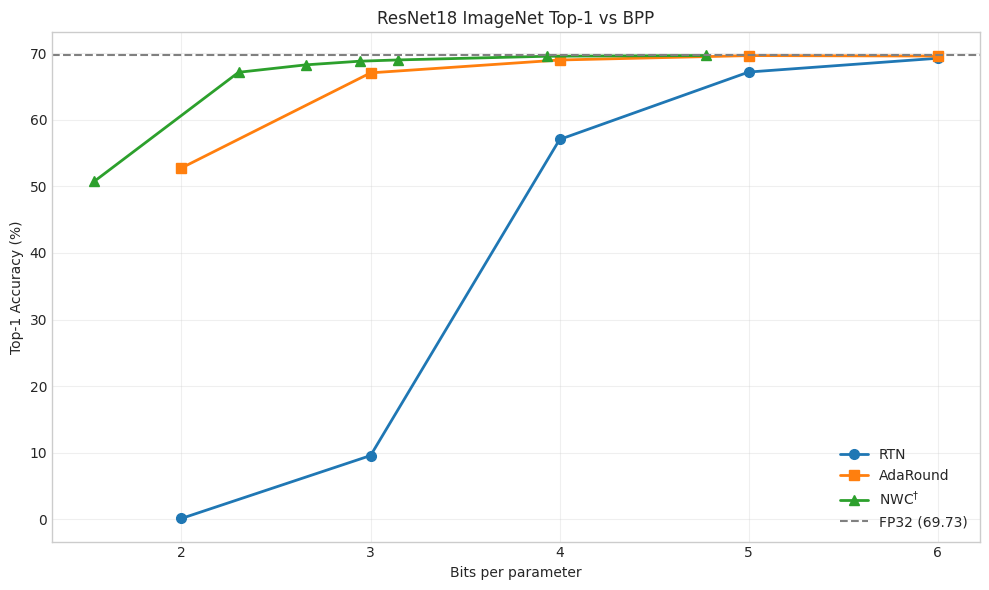

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    baseline_plot["bits_per_param"],
    baseline_plot["top1"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="RTN",
)
ax.plot(
    adaround_plot["bits_per_param"],
    adaround_plot["top1"],
    marker="s",
    linewidth=2,
    markersize=7,
    label="AdaRound",
)
ax.plot(
    nwc_plot["bits_per_param"],
    nwc_plot["top1"],
    marker="^",
    linewidth=2,
    markersize=7,
    label=r'NWC$^†$',
)

# for _, row in nwc_plot.iterrows():
#     ax.annotate(
#         row["lambda_tag"],
#         (row["bits_per_param"], row["top1"]),
#         textcoords="offset points",
#         xytext=(5, 5),
#         fontsize=8,
#     )

ax.axhline(
    fp32_top1,
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label=f"FP32 ({fp32_top1:.2f})",
)

ax.set_title("ResNet18 ImageNet Top-1 vs BPP")
ax.set_xlabel("Bits per parameter")
ax.set_ylabel("Top-1 Accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
comparison_df = pd.concat([
    baseline_plot.assign(label=baseline_plot["bits_per_param"].map(lambda x: f"W{int(x)}")),
    adaround_plot.assign(label=adaround_plot["bits_per_param"].map(lambda x: f"W{int(x)}")),
    nwc_plot.assign(label=nwc_plot["lambda_tag"]),
], ignore_index=True)

comparison_df = comparison_df[["method", "label", "bits_per_param", "top1"]].sort_values(
    ["method", "bits_per_param"]
).reset_index(drop=True)
comparison_df


,method,label,bits_per_param,top1
0,AdaRound,W2,2.0000,52.7814
1,AdaRound,W3,3.0000,67.0665
2,AdaRound,W4,4.0000,68.9986
3,AdaRound,W5,5.0000,69.6601
4,AdaRound,W6,6.0000,69.5946
5,Baseline Quant,W2,2.0000,0.1076
6,Baseline Quant,W3,3.0000,9.5576
7,Baseline Quant,W4,4.0000,57.0591
8,Baseline Quant,W5,5.0000,67.1908
9,Baseline Quant,W6,6.0000,69.2638


In [5]:
output_path = NWC_SWEEP_DIR.parent / "resnet18_top1_vs_bits_comparison.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")
print(output_path)


/home/jgryu/workspace/weight_compression/comp_cnn/resnet18_top1_vs_bits_comparison.png
